In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.optimize import curve_fit
reduced_raw_data = pd.read_csv(r'DATA\RAW\reduced_raw_data.csv')
reduced_raw_data_clean = reduced_raw_data[reduced_raw_data['a'].notna()]
sma_data = reduced_raw_data_clean['a']

Narrow binaries ORB6: 2177
Wide binaries ORB6: 8
Narrow binaries SB9: 501
Wide binaries SB9: 23


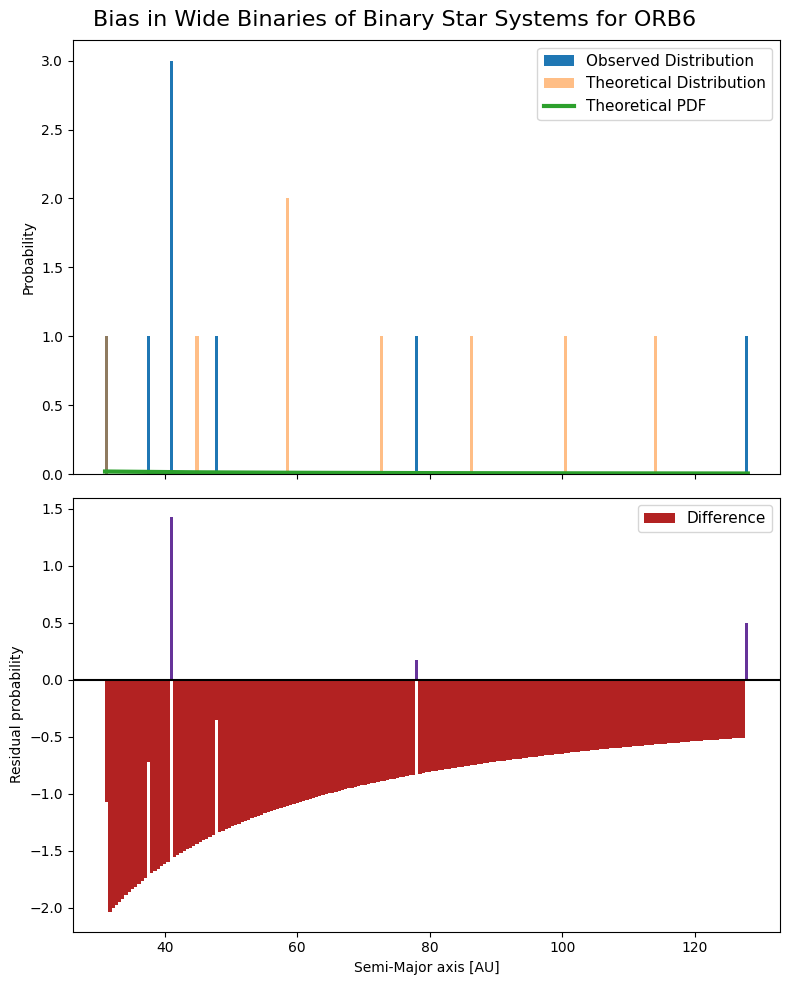

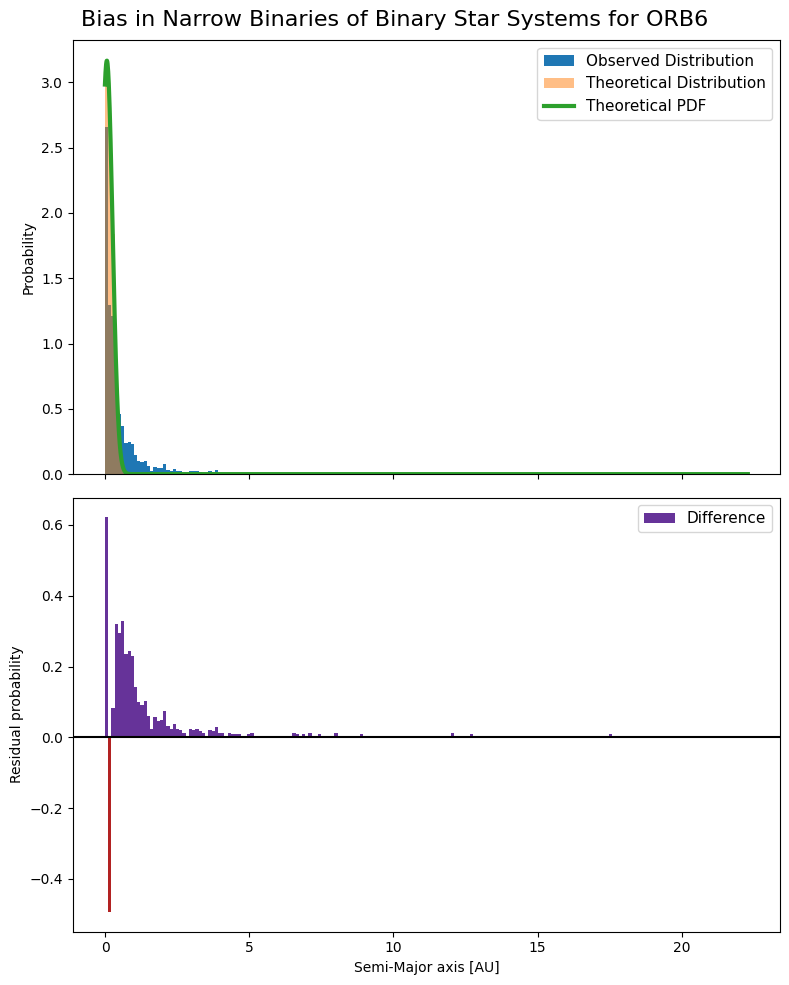

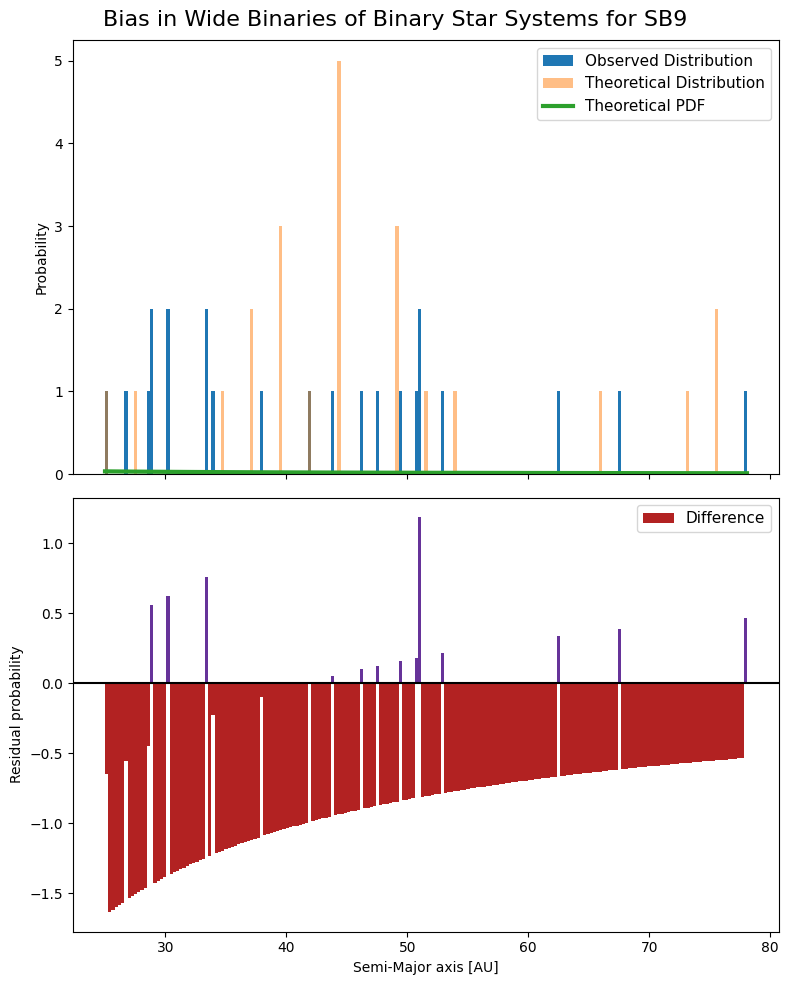

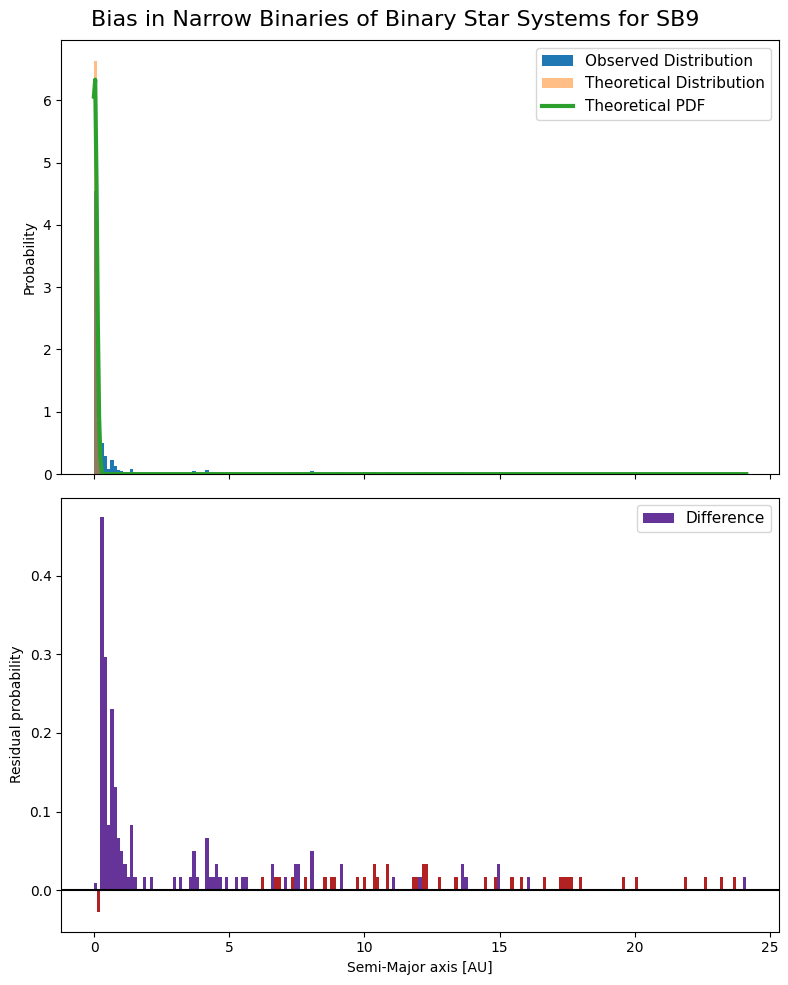

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.optimize import curve_fit

def öpik_law(C, a):
    'Distribution for wide binaries'
    N = C*(1/a)
    return N

def log_normal_dist(a, sigma, mu):
    'Log Normal Distribution for narrow binaries'
    N = (1/(np.sqrt(2*np.pi)*sigma))*np.exp(-(((a-mu)/sigma)**2)/2)
    return N

def normal_dist(a, sigma, mu):
    'Normal Distribution for narrow binaries'
    N = (1/(np.sqrt(2*np.pi)*sigma))*np.exp(-(((np.log(a)-mu)/sigma)**2)/2)
    return N

reduced_raw_data = pd.read_csv(r'DATA\RAW\reduced_raw_data.csv')
reduced_raw_data_clean = reduced_raw_data[reduced_raw_data['a'].notna()]
sma_data = reduced_raw_data_clean['a']
sma_data_ORB6 = sma_data[reduced_raw_data['catalogue'].str.contains(r"ORB6", na=False)]
sma_data_SB9 = sma_data[reduced_raw_data['catalogue'].str.contains(r"SB9", na=False)]

narrow_binaries_ORB6 = sma_data_ORB6[sma_data_ORB6 <= 25]
wide_binaries_ORB6 = sma_data_ORB6[sma_data_ORB6 >= 25]
narrow_binaries_SB9 = sma_data_SB9[sma_data_SB9 <= 25]
wide_binaries_SB9 = sma_data_SB9[sma_data_SB9 >= 25]

print(f'Narrow binaries ORB6: {len(narrow_binaries_ORB6)}')
print(f'Wide binaries ORB6: {len(wide_binaries_ORB6)}')
print(f'Narrow binaries SB9: {len(narrow_binaries_SB9)}')
print(f'Wide binaries SB9: {len(wide_binaries_SB9)}')

# ====================================================================================================================
# ORB6 Histogram Analysis
N = 200
bins_w_ORB6 = np.linspace(wide_binaries_ORB6.min(),wide_binaries_ORB6.max(),N)

a_w_ORB6 = np.linspace(wide_binaries_ORB6.min(), wide_binaries_ORB6.max(),len(wide_binaries_ORB6))

counts_w_ORB6, bin_edges_w_ORB6 = np.histogram(wide_binaries_ORB6, bins=bins_w_ORB6, density=False)
centers_w_ORB6 = (bin_edges_w_ORB6[:-1] + bin_edges_w_ORB6[1:]) / 2

popt_w_ORB6, pcov_w_ORB6 = curve_fit(öpik_law, xdata=centers_w_ORB6[counts_w_ORB6 > 0], ydata=counts_w_ORB6[counts_w_ORB6 > 0])

prob_w_ORB6 = öpik_law(C=popt_w_ORB6[0], a=a_w_ORB6)/np.sum(öpik_law(C=popt_w_ORB6[0], a=a_w_ORB6))

samples_w_ORB6 = np.random.choice(a_w_ORB6, size=len(wide_binaries_ORB6), p=prob_w_ORB6)

counts_samples_w_ORB6, bins_samples_w_ORB6 = np.histogram(samples_w_ORB6, bins=bins_w_ORB6, density=False)

öpik_dist_ORB6 = öpik_law(C=popt_w_ORB6[0], a=centers_w_ORB6)

hist_diff_w_ORB6 = counts_w_ORB6 - öpik_dist_ORB6

fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 10), sharex=True)

#Top subplot
ax1.hist(wide_binaries_ORB6, bins=bins_w_ORB6,density=False,label='Observed Distribution')

ax1.hist(samples_w_ORB6, bins=bins_w_ORB6, density=False, alpha=0.5, label='Theoretical Distribution')

#Plot normalized PDF
ax1.plot(a_w_ORB6, prob_w_ORB6 / (a_w_ORB6[1] - a_w_ORB6[0]), label='Theoretical PDF', lw =3)

ax1.set_yscale('linear')

ax1.set_ylabel('Probability')
ax1.legend(fontsize = 11)

#Bottom subplot
colors = ['rebeccapurple' if v > 0 else 'firebrick' for v in hist_diff_w_ORB6]
ax2.bar(centers_w_ORB6, hist_diff_w_ORB6, width=np.diff(bins_w_ORB6), color=colors, align='center', label='Difference')

ax2.axhline(0, color='black')

ax2.set_xlabel('Semi-Major axis [AU]')
ax2.set_ylabel('Residual probability')
ax2.legend(fontsize = 11)

plt.suptitle('Bias in Wide Binaries of Binary Star Systems for ORB6', size = 16)
plt.tight_layout()
plt.show()

# ====================================================================================================================

bins_n_ORB6 = np.linspace(narrow_binaries_ORB6.min(), narrow_binaries_ORB6.max(), N)

a_n_ORB6 = np.linspace(narrow_binaries_ORB6.min(), narrow_binaries_ORB6.max(),len(narrow_binaries_ORB6))

counts_n_ORB6, bin_edges_n_ORB6 = np.histogram(narrow_binaries_ORB6, bins=bins_n_ORB6, density=True)
centers_n_ORB6 = (bin_edges_n_ORB6[:-1] + bin_edges_n_ORB6[1:]) / 2

popt_n_ORB6, pcov_n_ORB6 = curve_fit(log_normal_dist, xdata=centers_n_ORB6[counts_n_ORB6 > 0], ydata=counts_n_ORB6[counts_n_ORB6 > 0])

prob_n_ORB6 = log_normal_dist(a=a_n_ORB6, sigma=popt_n_ORB6[0], mu=popt_n_ORB6[1]) / np.sum(log_normal_dist(a=a_n_ORB6, sigma=popt_n_ORB6[0], mu=popt_n_ORB6[1]))

samples_n_ORB6 = np.random.choice(a_n_ORB6, size=len(narrow_binaries_ORB6), p=prob_n_ORB6)

counts_samples_n_ORB6, bins_samples_n_ORB6 = np.histogram(samples_n_ORB6, bins=bins_n_ORB6, density=True)

log_normal_dist_ORB6 = log_normal_dist(a=centers_n_ORB6, sigma=popt_n_ORB6[0], mu=popt_n_ORB6[1])

hist_diff_n_ORB6 = counts_n_ORB6 - log_normal_dist_ORB6

fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 10), sharex=True)

#Top subplot
ax1.hist(narrow_binaries_ORB6,bins=bins_n_ORB6, density=True, label='Observed Distribution')

ax1.hist(samples_n_ORB6, bins=bins_n_ORB6, density=True, alpha=0.5, label='Theoretical Distribution')

#Plot normalized PDF
ax1.plot(a_n_ORB6, prob_n_ORB6 / (a_n_ORB6[1] - a_n_ORB6[0]), label='Theoretical PDF', lw =3)

ax1.set_yscale('linear')

ax1.set_ylabel('Probability')
ax1.legend(fontsize = 11)

#Bottom subplot
colors = ['rebeccapurple' if v > 0 else 'firebrick' for v in hist_diff_n_ORB6]
ax2.bar(centers_n_ORB6, hist_diff_n_ORB6, width=np.diff(bins_n_ORB6),color=colors, align='center',label='Difference')

ax2.axhline(0, color='black')

ax2.set_xlabel('Semi-Major axis [AU]')
ax2.set_ylabel('Residual probability')
ax2.legend(fontsize = 11)

plt.suptitle('Bias in Narrow Binaries of Binary Star Systems for ORB6', size = 16)
plt.tight_layout()
plt.savefig(r'C:\Users\ATWde\OneDrive - Delft University of Technology\Documenten\GitHub\Orbital-and-physical-parameter-distribution-of-Binary-Systems\Media\Narrow_binaries_ORB6.svg', format='svg')
plt.show()

# # ====================================================================================================================
# # SB9 Histogram Analysis
N = 200
bins_w_SB9 = np.linspace(wide_binaries_SB9.min(),wide_binaries_SB9.max(),N)

a_w_SB9 = np.linspace(wide_binaries_SB9.min(), wide_binaries_SB9.max(),len(wide_binaries_SB9))

counts_w_SB9, bin_edges_w_SB9 = np.histogram(wide_binaries_SB9, bins=bins_w_SB9, density=False)
centers_w_SB9 = (bin_edges_w_SB9[:-1] + bin_edges_w_SB9[1:]) / 2

popt_w_SB9, pcov_w_SB9 = curve_fit(öpik_law, xdata=centers_w_SB9[counts_w_SB9 > 0], ydata=counts_w_SB9[counts_w_SB9 > 0])

prob_w_SB9 = öpik_law(C=popt_w_SB9[0], a=a_w_SB9)/np.sum(öpik_law(C=popt_w_SB9[0], a=a_w_SB9))

samples_w_SB9 = np.random.choice(a_w_SB9, size=len(wide_binaries_SB9), p=prob_w_SB9)

counts_samples_w_SB9, bins_samples_w_SB9 = np.histogram(samples_w_SB9, bins=bins_w_SB9, density=False)

öpik_dist_SB9 = öpik_law(C=popt_w_SB9[0], a=centers_w_SB9)

hist_diff_w_SB9 = counts_w_SB9 - öpik_dist_SB9

fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 10), sharex=True)

#Top subplot
ax1.hist(wide_binaries_SB9, bins=bins_w_SB9,density=False,label='Observed Distribution')

ax1.hist(samples_w_SB9, bins=bins_w_SB9, density=False, alpha=0.5, label='Theoretical Distribution')

#Plot normalized PDF
ax1.plot(a_w_SB9, prob_w_SB9 / (a_w_SB9[1] - a_w_SB9[0]), label='Theoretical PDF', lw =3)

ax1.set_yscale('linear')

ax1.set_ylabel('Probability')
ax1.legend(fontsize = 11)

#Bottom subplot
colors = ['rebeccapurple' if v > 0 else 'firebrick' for v in hist_diff_w_SB9]
ax2.bar(centers_w_SB9, hist_diff_w_SB9, width=np.diff(bins_w_SB9), color=colors, align='center', label='Difference')

ax2.axhline(0, color='black')

ax2.set_xlabel('Semi-Major axis [AU]')
ax2.set_ylabel('Residual probability')
ax2.legend(fontsize = 11)

plt.suptitle('Bias in Wide Binaries of Binary Star Systems for SB9', size = 16)
plt.tight_layout()
plt.show()

# ====================================================================================================================

bins_n_SB9 = np.linspace(narrow_binaries_SB9.min(), narrow_binaries_SB9.max(), N)

a_n_SB9 = np.linspace(narrow_binaries_SB9.min(), narrow_binaries_SB9.max(),len(narrow_binaries_SB9))

counts_n_SB9, bin_edges_n_SB9 = np.histogram(narrow_binaries_SB9, bins=bins_n_SB9, density=True)
centers_n_SB9 = (bin_edges_n_SB9[:-1] + bin_edges_n_SB9[1:]) / 2

popt_n_SB9, pcov_n_SB9 = curve_fit(log_normal_dist, xdata=centers_n_SB9[counts_n_SB9 > 0], ydata=counts_n_SB9[counts_n_SB9 > 0])

prob_n_SB9 = log_normal_dist(a=a_n_SB9, sigma=popt_n_SB9[0], mu=popt_n_SB9[1]) / np.sum(log_normal_dist(a=a_n_SB9, sigma=popt_n_SB9[0], mu=popt_n_SB9[1]))

samples_n_SB9 = np.random.choice(a_n_SB9, size=len(narrow_binaries_SB9), p=prob_n_SB9)

counts_samples_n_SB9, bins_samples_n_SB9 = np.histogram(samples_n_SB9, bins=bins_n_SB9, density=True)

log_normal_dist_SB9 = log_normal_dist(a=centers_n_SB9, sigma=popt_n_SB9[0], mu=popt_n_SB9[1])

hist_diff_n_SB9 = counts_n_SB9 - log_normal_dist_SB9

fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 10), sharex=True)

#Top subplot
ax1.hist(narrow_binaries_SB9, bins=bins_n_SB9, density=True, label='Observed Distribution')

ax1.hist(samples_n_SB9, bins=bins_n_SB9, density=True, alpha=0.5, label='Theoretical Distribution')

#Plot normalized PDF
ax1.plot(a_n_SB9, prob_n_SB9 / (a_n_SB9[1] - a_n_SB9[0]), label='Theoretical PDF', lw =3)

ax1.set_yscale('linear')

ax1.set_ylabel('Probability')
ax1.legend(fontsize = 11)

#Bottom subplot
colors = ['rebeccapurple' if v > 0 else 'firebrick' for v in hist_diff_n_ORB6]
ax2.bar(centers_n_SB9, hist_diff_n_SB9, width=np.diff(bins_n_SB9),color=colors, align='center',label='Difference')

ax2.axhline(0, color='black')

ax2.set_xlabel('Semi-Major axis [AU]')
ax2.set_ylabel('Residual probability')
ax2.legend(fontsize = 11)

plt.suptitle('Bias in Narrow Binaries of Binary Star Systems for SB9', size = 16)
plt.tight_layout()
plt.savefig(r'C:\Users\ATWde\OneDrive - Delft University of Technology\Documenten\GitHub\Orbital-and-physical-parameter-distribution-of-Binary-Systems\Media\Narrow_binaries_SB9.svg', format='svg')
plt.show()

# ====================================================================================================================